<a href="https://colab.research.google.com/github/Bamboohoccode/LLMs_From_Scratch/blob/main/Chapter_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

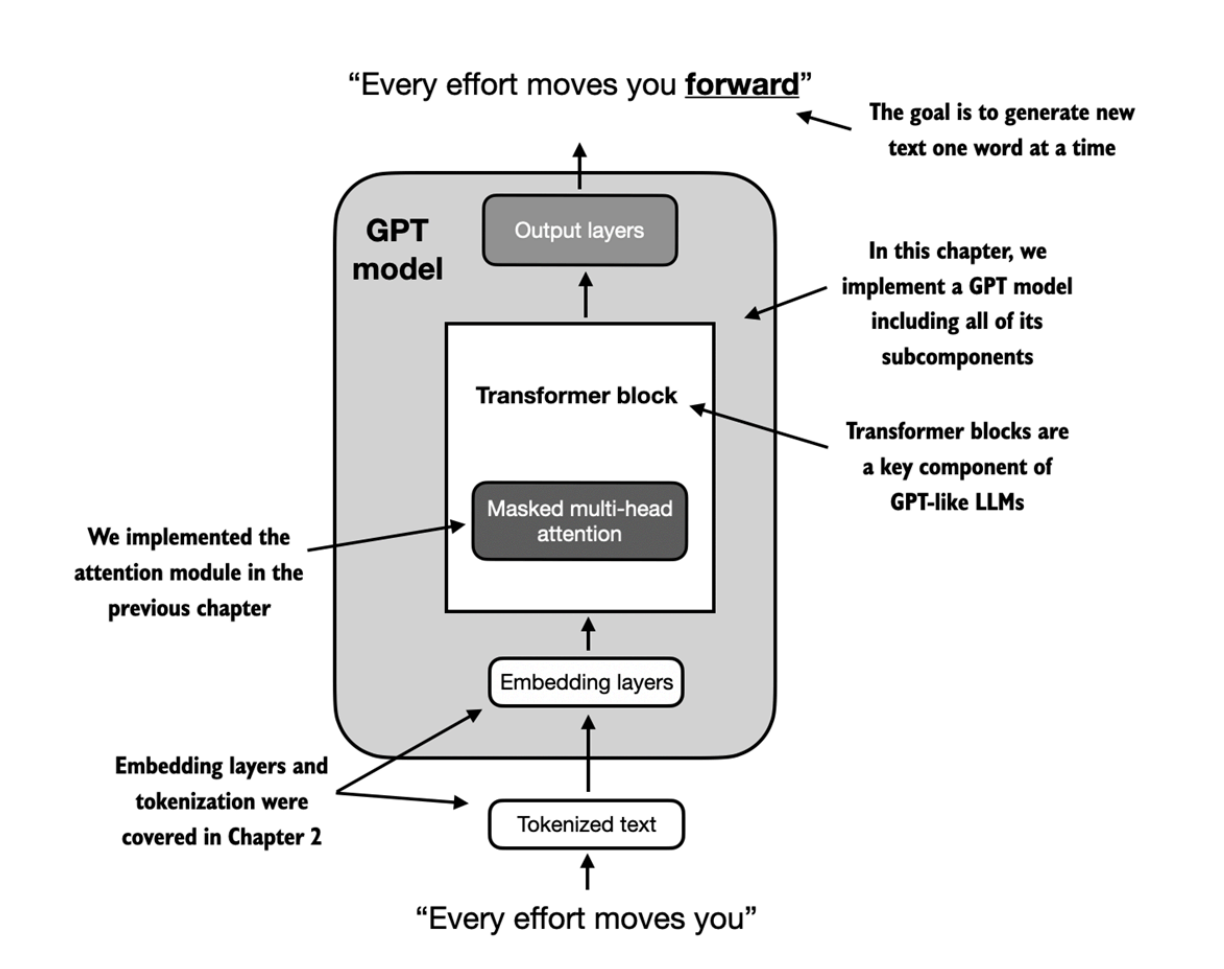

We specify the configuration of the small GPT-2 model via the following Python dictionary,
which we will use in the code examples later:

In [ ]:
import torch
import torch.nn as nn

In [ ]:
GPT_CONFIG_124M = {
"vocab_size": 50257, # Vocabulary size
"context_length": 1024, # Context length
"emb_dim": 768, # Embedding dimension
"n_heads": 12, # Number of attention heads
"n_layers": 12, # Number of layers
"drop_rate": 0.1, # Dropout rate
"qkv_bias": False # Query-Key-Value bias
}


# 4.1 Coding GPT Architecture

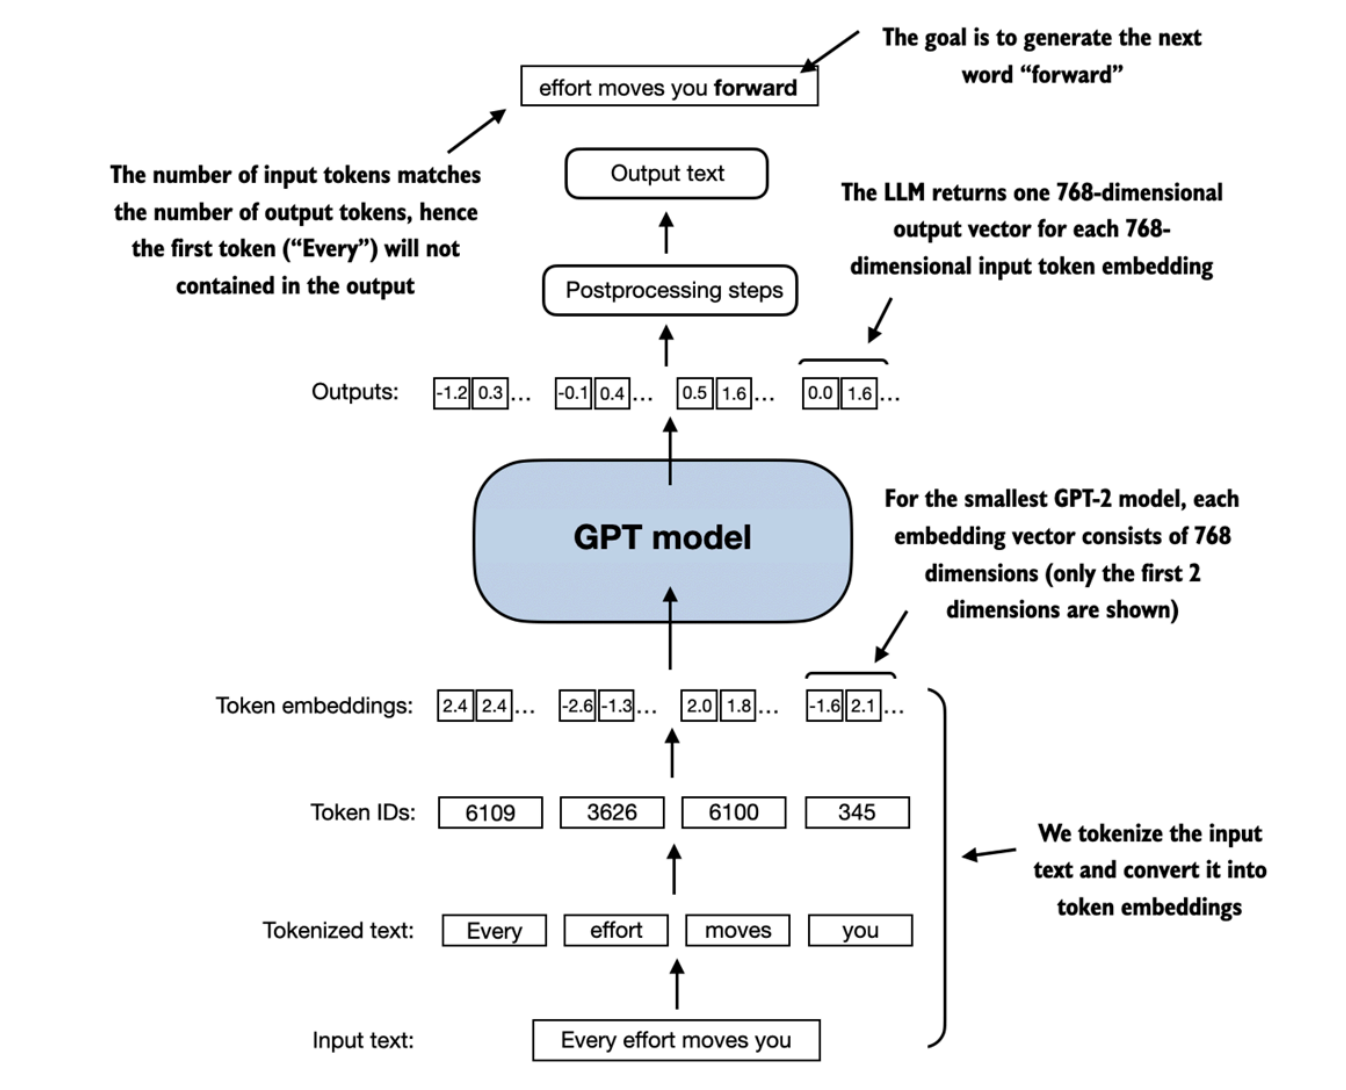

In [ ]:
class DummyGPTModel(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg['vocab_size'],cfg['emb_dim'])
        self.pos_emb = nn.Embedding(cfg['context_length'],cfg['emb_dim'])
        self.dropout = nn.Dropout(cfg['drop_rate'])
        self.trf_blocks = nn.Sequential(*[
            DummyTransformerBlock(cfg) for _ in range(cfg['n_layers'])
        ])
        self.final_norm = DummyLayerNorm(cfg)
        self.out_head = nn.Linear(cfg['emb_dim'],cfg['vocab_size'],bias = False)
    def forward(self,X):
        batch_size,seq_len = X.shape
        tok_embedded = self.tok_emb(X)
        pos_embedded = self.pos_emb(torch.arange(seq_len,device=X.device))
        x = tok_embedded + pos_embedded
        x = self.dropout(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        output = self.out_head(x)
        return output
class DummyTransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()
    def forward(self,X):
        return X
class DummyLayerNorm(nn.Module):
    def __init__(self,normalized_shape,eps = 1e-5):
        super().__init__()
    def forward(self,X):
        return X

Embedding step

In [ ]:
import tiktoken

txt1 = "Every effort moves you"
txt2 = "Every day holds a"
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch,dim = 0)
batch

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

In [ ]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
model(batch).shape

torch.Size([2, 4, 50257])

#4.2 Normalizing activations with layer normalization


The illustration of layer normalization

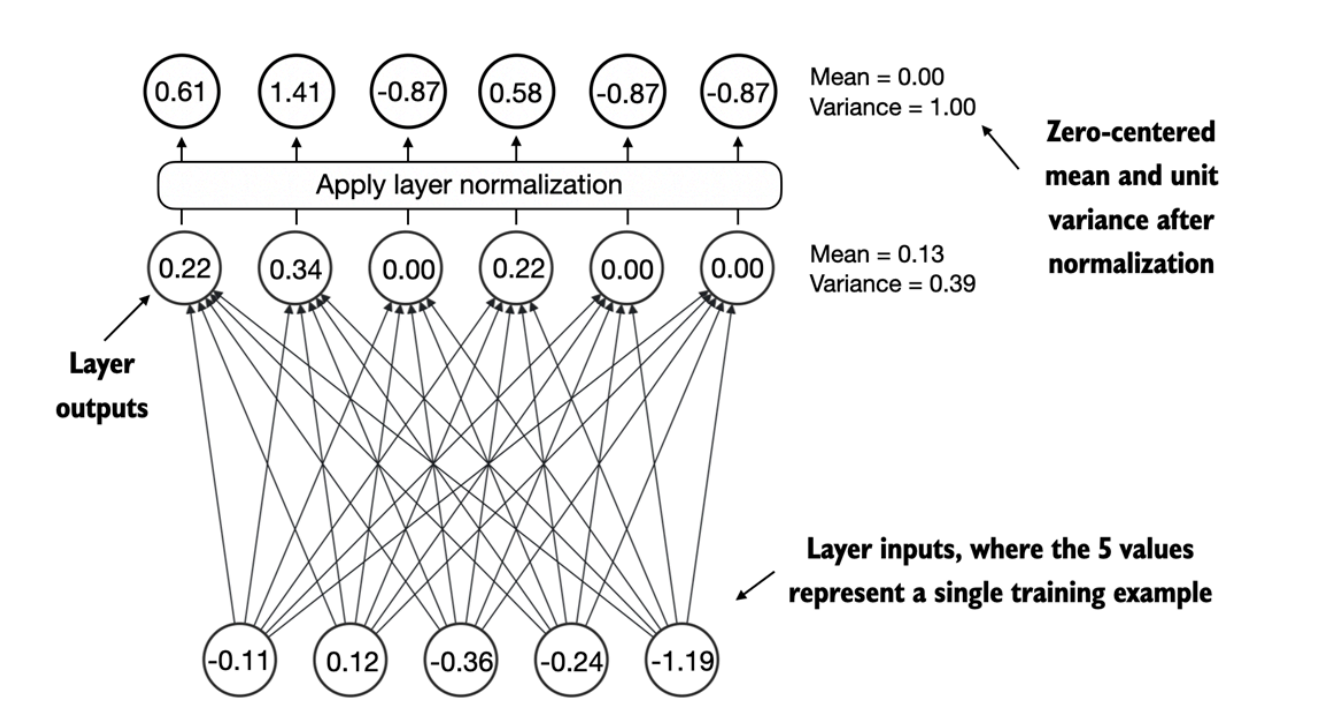

**Here is the example**

In [ ]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5)
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [ ]:
mean = out.mean(dim = -1,keepdim = True) # must use keepdim = True,try to see the reason.
std = out.std(dim = -1,keepdim = True)


In [ ]:
# Normalize
normalized = (out - mean) / std
normalized
normalized.std(dim = -1)

tensor([1., 1.], grad_fn=<StdBackward0>)

## Let's code the Normalize Class


[The reason why we use gamma and beta in LayerNorm](https://gemini.google.com/share/d082c23db0c3)

In [117]:
class LayerNorm(nn.Module):
    def __init__(self,emb_dim):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(emb_dim))
        self.beta = nn.Parameter(torch.ones(emb_dim))

    def forward(self,X):
        mean = X.mean(dim = -1,keepdim = True)
        std = X.std(dim = -1,keepdim = True,unbiased = False) # Important: unbiased must be setted = False
        output = (X - mean)/std
        return self.gamma * output + self.beta

In [ ]:
batch_example = torch.randn(2, 768)
layer = LayerNorm(GPT_CONFIG_124M['emb_dim'])
layer(batch_example)

torch.Size([2, 768])


tensor([[ 0.7982, -1.2220,  0.1044,  ...,  2.9716,  2.8318,  1.9432],
        [ 1.1119,  1.5795,  0.9535,  ...,  0.2268, -0.0886,  0.8565]],
       grad_fn=<AddBackward0>)

[Why we don't use BN](https://gemini.google.com/share/ce3c787e2d3f)

# 4.3 Implementing a feed forward network with GELU activations

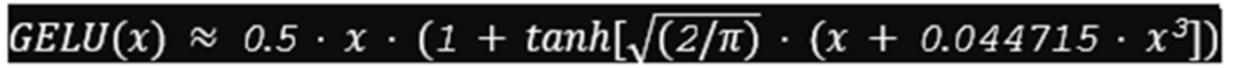

In [ ]:
class GeLU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) *
        (x + 0.044715 * torch.pow(x, 3))
        ))

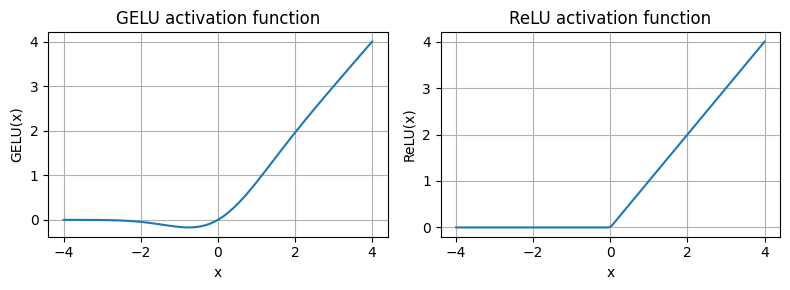

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 3))
x = torch.linspace(-4,4,100)
gelu,relu = GeLU(),nn.ReLU()
y_gelu = gelu(x)
y_relu = relu(x)
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()


The FeedForward module we implemented in this section plays a crucial role in enhancing
the model's ability to learn from and generalize the data. Although the input and output
dimensions of this module are the same, it internally expands the embedding dimension
into a higher-dimensional space through the first linear layer as illustrated in Figure 4.10.
This expansion is followed by a non-linear GELU activation, and then a contraction back to
the original dimension with the second linear transformation. Such a design allows for the
exploration of a richer representation space.

In [ ]:
class FeedForward(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg['emb_dim'],cfg['emb_dim'] * 4,bias = False),
            GeLU(),
            nn.Linear(cfg['emb_dim'] * 4,cfg['emb_dim'],bias = False)
        )
    def forward(self,X):
        return self.layers(X)



In [ ]:
GPT_CONFIG_124M

{'vocab_size': 50257,
 'context_length': 1024,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'qkv_bias': False}

In [ ]:
inputs_example = torch.rand(2,5,GPT_CONFIG_124M['emb_dim'])
feed_forward = FeedForward(GPT_CONFIG_124M)
feed_forward(inputs_example).shape

torch.Size([2, 5, 768])

# 4.4 Adding shortcut connections(Residualllllllllll)


Here is the advantage of using shortcut connections

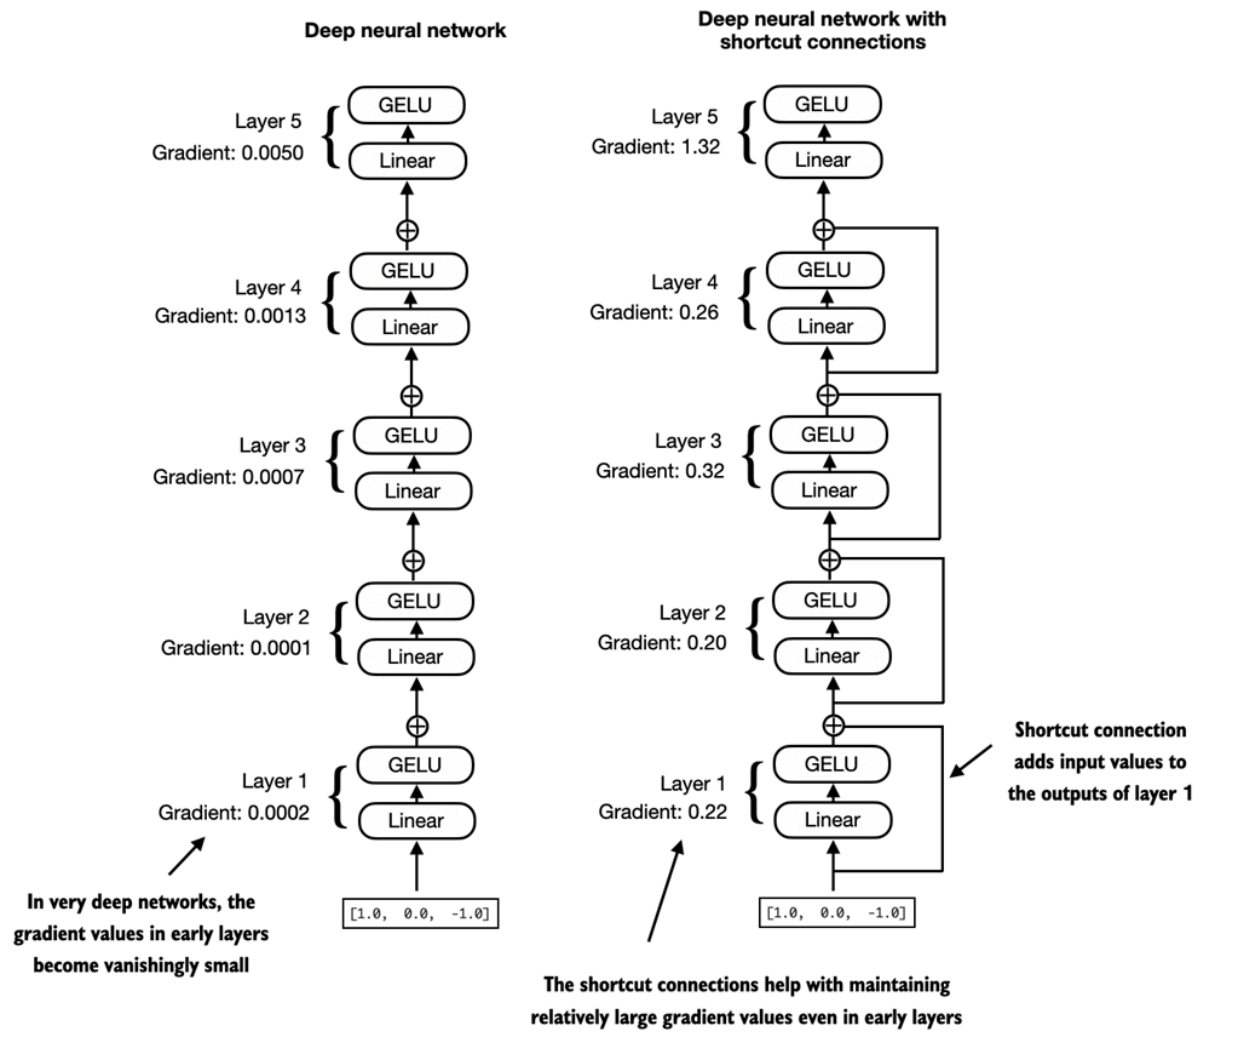

Let's code the simple example of this.

In [ ]:
class Neutral(nn.Module):
    def __init__(self,d_in,d_out,use_shortcut,output_size,num_layer):
        super().__init__()
        self.layers = nn.ModuleList([

        nn.Sequential(nn.Linear(d_in,d_out), GeLU())
        for _ in range(num_layer)

        ])


        self.use_shortcut = use_shortcut
        self.output =  nn.Linear(d_out,output_size,bias = False)
    def forward(self,X):
        for layer in self.layers:
            if self.use_shortcut:
                X = X + layer(X)
            else:
                X = layer(X)
        return self.output(X)

In [ ]:
sample_input = torch.tensor([[1., 0., -1.]])
sample_input.shape
neutral = Neutral(3,3,True,1,5)
neutral(sample_input)

tensor([[-0.1031]], grad_fn=<MmBackward0>)

In [ ]:
def print_grad(model,X):
    output = model(X)
    target = torch.tensor([[0.0]])
    criterion = nn.MSELoss()
    loss = criterion(target,output)
    loss.backward()
    for name, param in model.named_parameters():
        if 'weight' in name:
        # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

**The neutral with shortcut connection have a great gradient and the vanishing gradient didn't happen**

In [ ]:
print_grad(neutral,sample_input)

layers.0.0.weight has gradient mean of 0.035835836082696915
layers.1.0.weight has gradient mean of 0.044581953436136246
layers.2.0.weight has gradient mean of 0.022525232285261154
layers.3.0.weight has gradient mean of 0.06594234704971313
layers.4.0.weight has gradient mean of 0.05089767277240753
output.weight has gradient mean of 0.28354206681251526


In [ ]:
neutral_2 = Neutral(3,3,False,1,5)
print_grad(neutral_2,sample_input)

layers.0.0.weight has gradient mean of 7.291760994121432e-06
layers.1.0.weight has gradient mean of 3.326115620438941e-05
layers.2.0.weight has gradient mean of 7.325314800255e-05
layers.3.0.weight has gradient mean of 0.0006181434146128595
layers.4.0.weight has gradient mean of 0.002277341205626726
output.weight has gradient mean of 0.011895888485014439


# 4.5 Connecting attention and linear layers in a transformer block


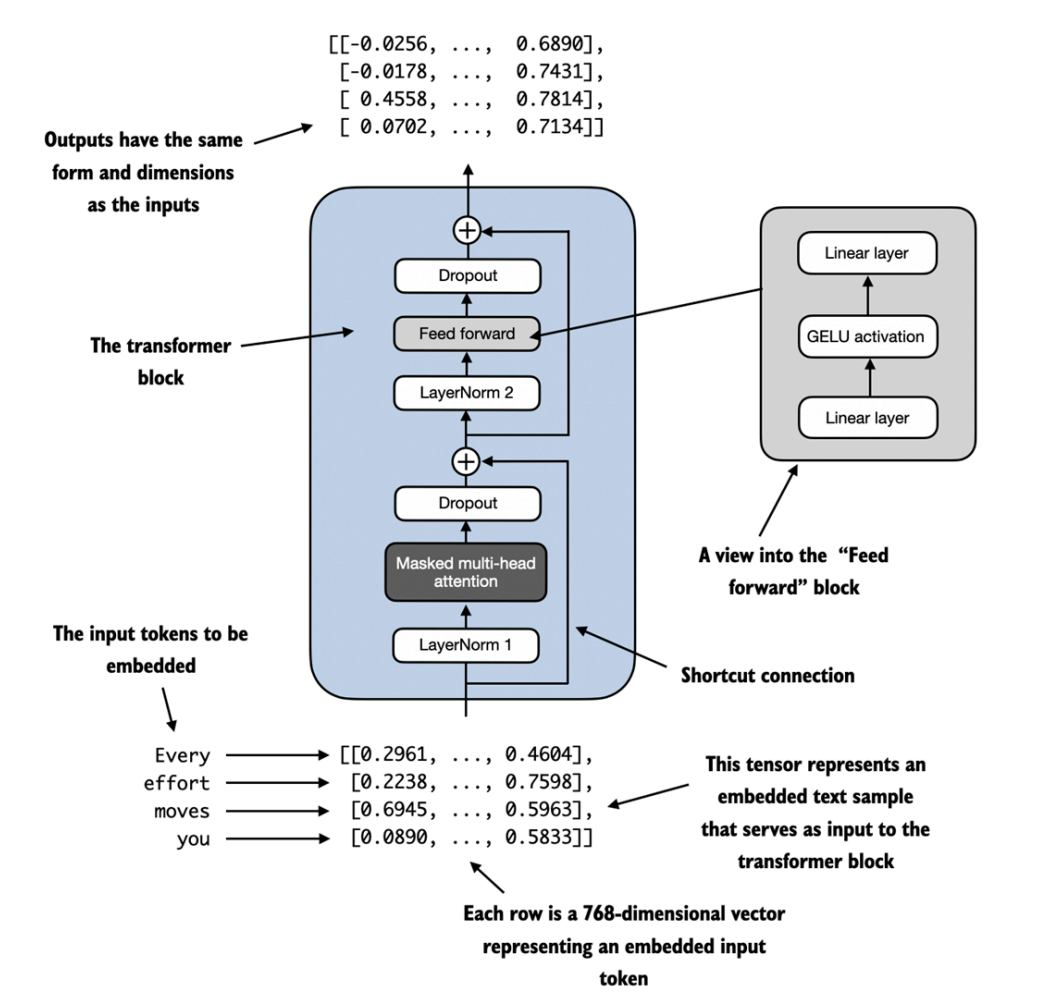

Transformer class

# Import class từ file gg colab khác


In [71]:
# 1. Cài đặt thư viện hỗ trợ import file .ipynb
!pip install import-ipynb

import import_ipynb
import os
from google.colab import drive

# 2. Mount Drive (nếu chưa mount)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 3. Di chuyển đến thư mục chứa file
os.chdir('/content/drive/MyDrive/Colab Notebooks')

# 4. Import file notebook của bạn (đảm bảo file tên là MultiHeadAttention.ipynb)
import MultiHeadAttention as MHA_File

In [120]:
class TransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.LayerNorm1 = LayerNorm(cfg['emb_dim'])
        self.LayerNorm2 = LayerNorm(cfg['emb_dim'])
        # Lưu ý trong cách import class MultiHeadAttention
        self.att = MHA_File.MultiHeadAttention(d_in = cfg['emb_dim'],
                                               d_out = cfg['emb_dim'],
                                               context_length = cfg['context_length'],
                                               dropout = cfg['drop_rate'],
                                               num_heads = cfg['n_heads'],
                                               bias = cfg['qkv_bias'])
        self.ff = FeedForward(cfg)
        self.dropout = nn.Dropout(cfg['drop_rate'])
    def forward(self,X):

        shortcut = X
        X = self.LayerNorm1(X)
        X = self.att(X)
        X = self.dropout(X)
        X += shortcut
        shortcut = X
        X = self.LayerNorm2(X)
        X = self.ff(X)
        X = self.dropout(X)
        X += shortcut

        return X




In [116]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768) #A
block = TransformerBlock(GPT_CONFIG_124M)

output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

sd
asd
torch.Size([2, 4, 768])
Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


# 4.6 Coding the GPT model


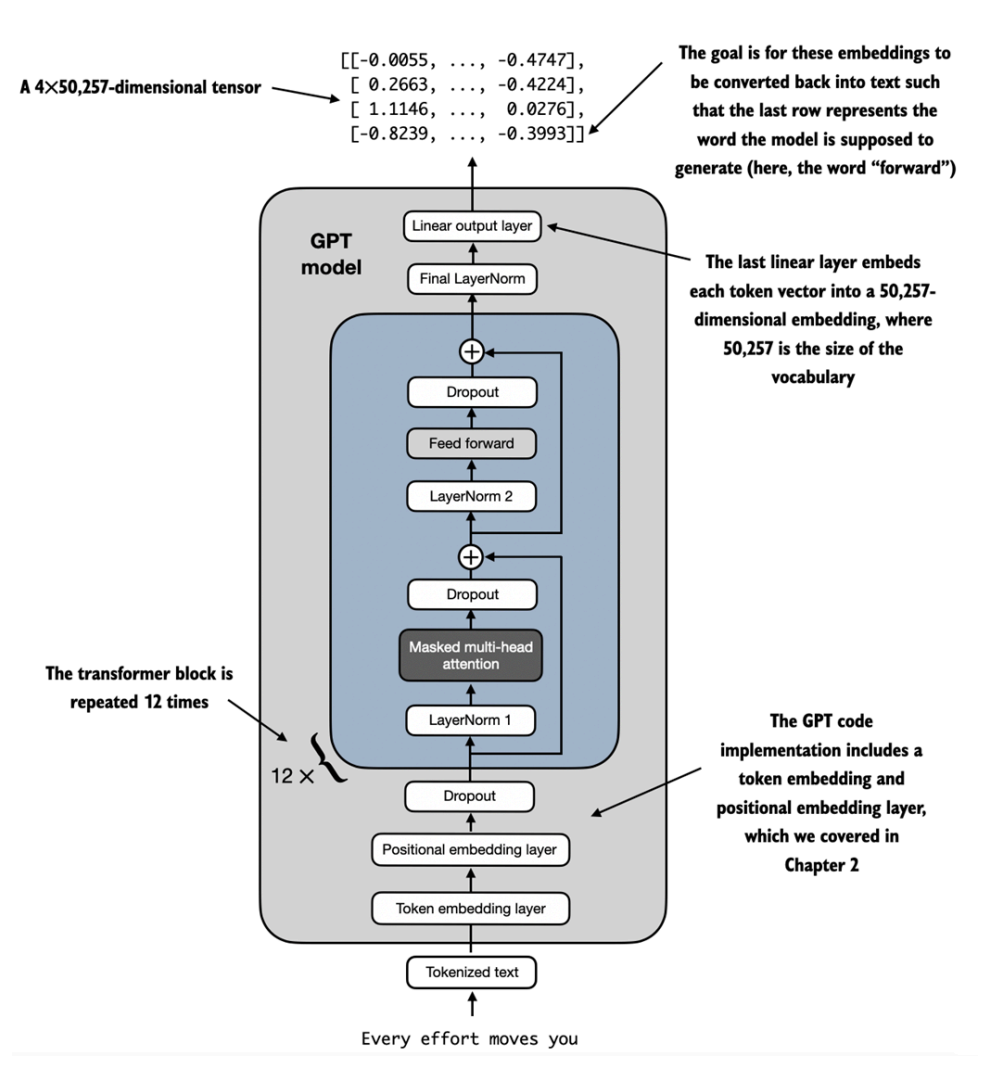

In [121]:
class GPTModel(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.tok_embedded = nn.Embedding(cfg['vocab_size'],cfg['emb_dim'])
        self.pos_embedded = nn.Embedding(cfg['context_length'],cfg['emb_dim'])
        self.dropout = nn.Dropout(cfg['drop_rate'])

        self.transformer = nn.Sequential( *[TransformerBlock(cfg)
        for _ in range(cfg['n_layers'])])

        self.layernorm = LayerNorm(cfg['emb_dim'])
        self.output = nn.Linear(cfg['emb_dim'],cfg['vocab_size'])
    def forward(self,X):
        b,seq_len = X.shape
        tok_embedded = self.tok_embedded(X)
        pos_embedded = self.pos_embedded(torch.arange(seq_len,device = X.device))
        embedded = tok_embedded + pos_embedded
        embedded = self.dropout(embedded)
        embedded = self.transformer(embedded)
        embedded = self.layernorm(embedded)
        embedded = self.output(embedded)
        return embedded


In [122]:
GPT = GPTModel(GPT_CONFIG_124M)
out = GPT(batch)

print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.4331, -0.5274,  0.6502,  ...,  0.2490,  0.7486,  0.5911],
         [-0.6530, -1.0709,  0.9677,  ..., -0.0932,  1.4283,  0.1156],
         [-0.6270, -0.6934,  0.0967,  ...,  0.0323,  1.5217,  0.7455],
         [-0.2085, -0.0162,  0.1376,  ...,  0.8175,  1.2454,  0.6078]],

        [[-1.2538,  0.0093,  0.2785,  ..., -0.2025,  0.7184,  0.6569],
         [-0.2995, -1.4747,  0.4178,  ...,  0.2584,  0.6864,  0.8688],
         [-0.1467, -0.0663,  0.3801,  ...,  0.2255,  0.6592,  0.7961],
         [-0.3791, -0.1347,  0.7188,  ..., -0.2081,  0.8058,  1.7003]]],
       grad_fn=<ViewBackward0>)


In [139]:
total_params = sum(p.numel() for p in GPT.parameters())
print(f"Total number of parameters: {total_params:,}")
total_size_bytes = total_params * 4 #A
total_size_mb = total_size_bytes / (1024 * 1024) #B
print(f"Total size of the model: {total_size_mb:.2f} MB")


Total number of parameters: 163,004,497
Total size of the model: 621.81 MB


#EXERCISE 4.1 NUMBER OF PARAMETERS IN FEED FORWARD AND ATTENTION MODULES
Calculate and compare the number of parameters that are contained in the feed
forward module and those that are contained in the multi-head attention module.


Ta thấy nó bằng nhau :v

In [138]:
ff = FeedForward(GPT_CONFIG_124M)
feed_forward_params = sum(p.numel() for p in ff.parameters())
print(f"Total number of parameters: {feed_forward_params:,}")
T_block = TransformerBlock(GPT_CONFIG_124M)

ff_att_params = sum(p.numel() for p in T_block.ff.parameters())
print(f"Total number of parameters: {ff_att_params:,}")


Total number of parameters: 4,718,592
Total number of parameters: 4,718,592


# 4.7 Generating text

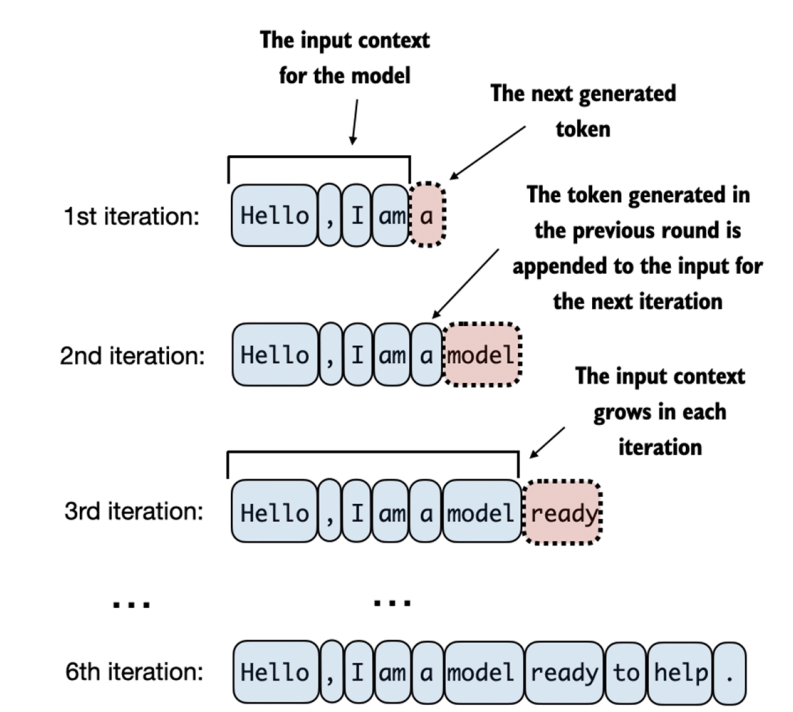

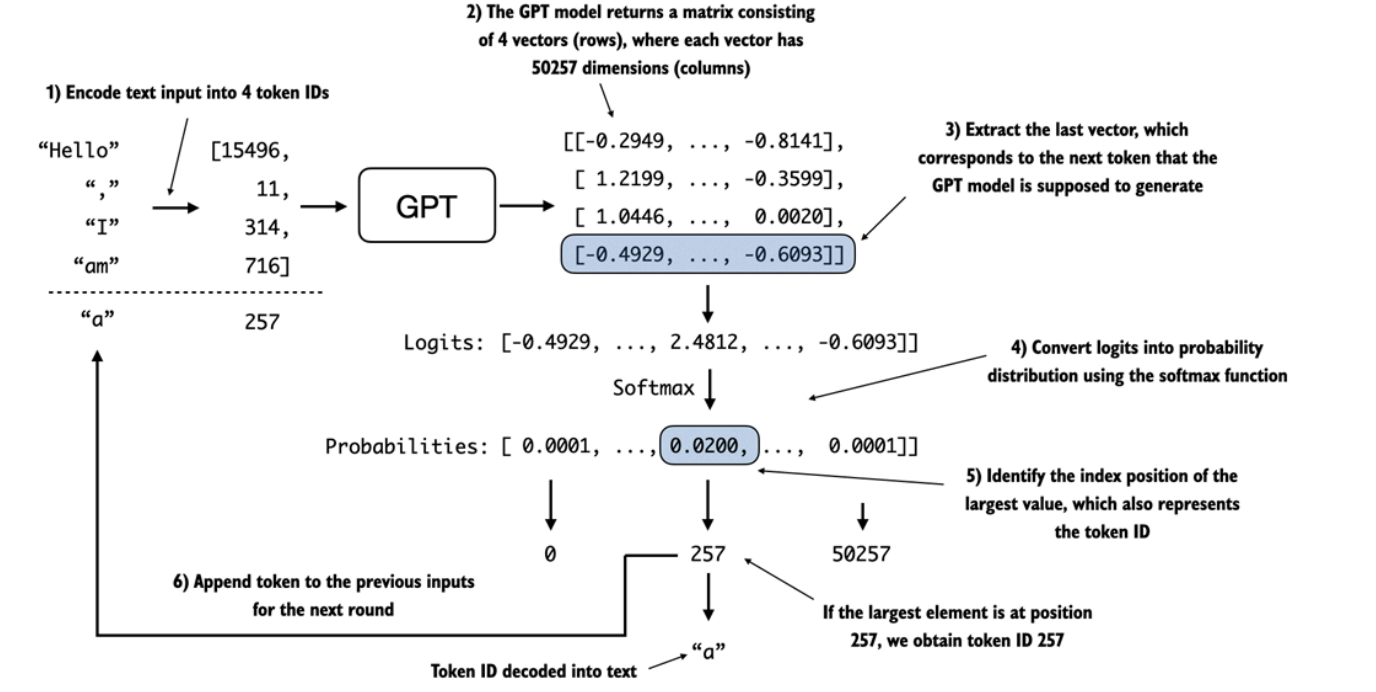

In [161]:
def generate_text_simple(model,X,max_new_tokens,context_size):
    for _ in range(max_new_tokens):
        X_cal = X[:,-context_size:]
        with torch.no_grad():
            logits = model(X_cal)
        logits = logits[:,-1,:] # Lay cai cuoi cung
        logits = torch.softmax(logits,dim = -1)
        X_next = torch.argmax(logits,dim = -1,keepdim = True)
        X = torch.cat((X,X_next),dim = -1)
    return X


idx_cond = idx[:, -context_size:] (Dấu trừ cắt lát - Slicing)
Dấu trừ này dùng để lấy N phần tử cuối cùng của chuỗi đang có.

Tại sao cần? Mô hình GPT-2 có một giới hạn vật lý gọi là context_length (ví dụ 1024 token). Nếu bạn cứ để chuỗi idx dài vô tận, khi nó vượt quá giới hạn này, mô hình sẽ báo lỗi vì không đủ vị trí (positional embeddings) để xử lý.

Cơ chế: Khi bạn viết [-context_size:], Python sẽ đếm ngược từ cuối chuỗi về phía trước. Điều này đảm bảo mô hình luôn được cung cấp một "cửa sổ ngữ cảnh" mới nhất và hợp lệ.

Ví dụ: Nếu context_size = 3 và chuỗi hiện tại là [1, 2, 3, 4, 5, 6], thì idx_cond sẽ chỉ lấy [4, 5, 6].

In [170]:
GPT.eval()
start_context = "Hello I am"
tokenizer = tiktoken.get_encoding("gpt2")
encoded = tokenizer.encode(start_context)
print(encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
max_new_tokens = 3
context_size = GPT_CONFIG_124M['context_length']
output = generate_text_simple(GPT,encoded_tensor,max_new_tokens,context_size)




[15496, 314, 716]


In [171]:
text_output = tokenizer.decode(output.squeeze(0).tolist())
#Nó có thể gen ra dấu cách hoặc không nên có thể dính lại kiểu này.
text_output

'Hello I am telescopesRangeymm'